In [4]:
#exercice 1

import random

def creer_table_hachage(m):
    return [[] for _ in range(m)] 

def h(c, m):
    return c % m

def inserer(TH, c):
    TH[h(c,len(TH))].append(c)

def rechercher(TH, c):
    return c in TH[h(c,len(TH))]

def supprimer(TH, c):
    m = len(TH)
    index = h(c, m)
    if c in TH[index]:
        TH[index].remove(c)

def test(m):
    print(f"\n=== Test pour m = {m} ===")
    n = 2*m
    TH = creer_table_hachage(m)

    valeurs = [random.randint(0, 10000000) for _ in range(n)]

    for v in valeurs:
        inserer(TH, v)

    print("Insertion terminée !")

    test_val = valeurs[random.randint(1,n-1)]
    print(f"Recherche {test_val} →", rechercher(TH, test_val))

    supprimer(TH, test_val)
    print("Après suppression →", rechercher(TH, test_val))

    return TH


for m in [100, 1000, 10000, 100000]:
    test(m)



=== Test pour m = 100 ===
Insertion terminée !
Recherche 8454363 → True
Après suppression → False

=== Test pour m = 1000 ===
Insertion terminée !
Recherche 9160889 → True
Après suppression → False

=== Test pour m = 10000 ===
Insertion terminée !
Recherche 276130 → True
Après suppression → False

=== Test pour m = 100000 ===
Insertion terminée !
Recherche 9186916 → True
Après suppression → False


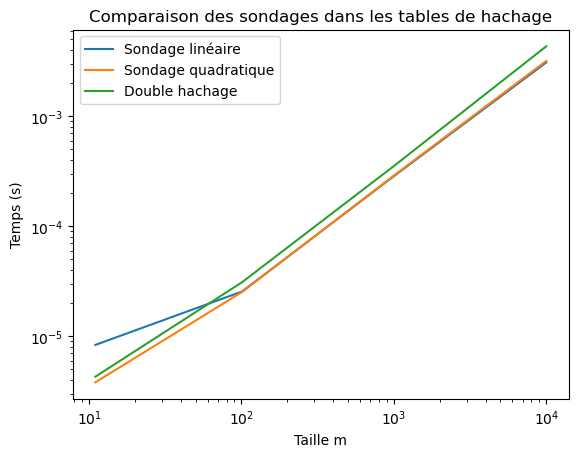

In [4]:
#exercice 2

import random
import time
import matplotlib.pyplot as plt

def create_table(m):
    return [None] * m


def h1(c, m):
    return c % m


def h2(c, m):
    return 1 + (c % (m - 1))

def hash_linear(c, i, m, a=1):
    return (h1(c, m) + i * a) % m


def hash_quadratic(c, i, m):
    return (h1(c, m) + i * i) % m


def hash_double(c, i, m):
    return (h1(c, m) + i * h2(c, m)) % m


def insert(table, c, hash_func, m):
    for i in range(m):
        idx = hash_func(c, i, m)
        if table[idx] in (None, "DELETED"):
            table[idx] = c
            return True
    return False


def search(table, c, hash_func, m):
    for i in range(m):
        idx = hash_func(c, i, m)
        if table[idx] is None:
            return False
        if table[idx] == c:
            return True
    return False


def delete(table, c, hash_func, m):
    for i in range(m):
        idx = hash_func(c, i, m)
        if table[idx] is None:
            return False
        if table[idx] == c:
            table[idx] = "DELETED"
            return True
    return False


def time_insert(m):
    n = int(0.7 * m)
    values = random.sample(range(m), n)

    methods = {
        "Lineaire": hash_linear,
        "Quadratique": hash_quadratic,
        "Double": hash_double
    }

    times = {}

    for name, func in methods.items():
        table = create_table(m)
        start = time.time()

        for v in values:
            insert(table, v, func, m)

        end = time.time()
        times[name] = end - start

    return times



ms = [11, 101, 1009, 10007]  # nombres premiers proches de 10, 100, 1000, 10000

results = {"Lineaire": [], "Quadratique": [], "Double": []}

for m in ms:
    t = time_insert(m)
    for k in results:
        results[k].append(t[k])


plt.plot(ms, results["Lineaire"], label="Sondage linéaire")
plt.plot(ms, results["Quadratique"], label="Sondage quadratique")
plt.plot(ms, results["Double"], label="Double hachage")
plt.xlabel("Taille m")
plt.ylabel("Temps (s)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Comparaison des sondages dans les tables de hachage")
plt.show()


In [10]:
#exercice 3

import random

def h1(x, m):
    return x % m
def h2(x, m):
    return (x * 7) % m
def h3(x, m):
    return (x * 13) % m
def h4(x, m):
    return (x * 17) % m

hash_funcs = {
    2: [h1, h2],
    3: [h1, h2, h3],
    4: [h1, h2, h3, h4]
}

def test_fp(m, n, k):
    table = [0] * m
    funcs = hash_funcs[k]

    inserted = random.sample(range(1000000), n)
    for x in inserted:
        for h in funcs:
            table[h(x, m)] = 1

    tests = random.sample(range(1000000, 2000000), n)
    fp = 0
    for x in tests:
        if all(table[h(x, m)] == 1 for h in funcs):
            fp += 1

    return (fp / n) * 100


m = 25000
n = 5000

for k in [2, 3, 4]:
    print(f"k = {k} → faux positifs = {test_fp(m, n, k):.2f}%")


k = 2 → faux positifs = 20.78%
k = 3 → faux positifs = 21.52%
k = 4 → faux positifs = 21.84%


In [56]:
#exercice 4

import random

def hash_functions(k, w):
    seeds = [random.randint(1, 10000) for _ in range(k)]
    funcs = []
    for s in seeds:
        def h(x, s=s):
            return (x * s) % w
        funcs.append(h)
    return funcs

def init_cms(k, w):
    return [[0 for _ in range(w)] for _ in range(k)]


def cms_add(cms, x, hash_funcs):
    k = len(hash_funcs)
    for i in range(k):
        idx = hash_funcs[i](x)
        cms[i][idx] += 1


def cms_estimate(cms, x, hash_funcs):
    k = len(hash_funcs)
    counts = [cms[i][hash_funcs[i](x)] for i in range(k)]
    return min(counts)


def test_cms():
    w = 1000  
    stream = [random.randint(0, 500) for _ in range(5000)]

    true_freq = {}
    for x in stream:
        true_freq[x] = true_freq.get(x, 0) + 1

    for k in [1, 2, 3, 4]:
        cms = init_cms(k, w)
        hash_funcs = hash_functions(k, w)

        for x in stream:
            cms_add(cms, x, hash_funcs)

        total_error = 0
        for x, tf in true_freq.items():
            total_error += cms_estimate(cms, x, hash_funcs) - tf

        print(f"k = {k} → erreur moyenne = {total_error / len(true_freq)}")

test_cms()


k = 1 → erreur moyenne = 10.031936127744512
k = 2 → erreur moyenne = 0.033932135728542916
k = 3 → erreur moyenne = 0.0
k = 4 → erreur moyenne = 0.0
